In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# -------------------------------------------------------------------------
# DATA LOADING & CLEANING SETUP
# -------------------------------------------------------------------------
df = pd.read_csv('q1-survey-cleaned.csv')

# Role-based subsets
vendor_df = df[df['role'] == 'Vendor'].copy()
diner_df = df[df['role'] == 'Diner'].copy()

print("=" * 65)
print(f" DATASET OVERVIEW: Total ({len(df)}), Vendors ({len(vendor_df)}), Diners ({len(diner_df)}) ")
print("=" * 65)

 DATASET OVERVIEW: Total (72), Vendors (22), Diners (50) 


In [14]:
# =========================================================================
# PART 1: OVERALL MARKET ANALYSIS (Universal Consumer & Market Overview)
# =========================================================================
print("\n【PART 1: OVERALL MARKET ANALYSIS (N=72)】")

print("1. Overall Age Distribution (%):\n", df['age_group'].value_counts(normalize=True) * 100)

print("\n2. Overall Weekly Dining Visits (%):\n", df['visits_per_week'].value_counts(normalize=True).sort_index() * 100)

print("\n3. Overall Usual Ordering Method (%):\n", df['usual_order_method'].value_counts(normalize=True) * 100)

overall_app_will = df['willingness_to_use_app'].dropna()
print(f"\n4. Overall Willingness to Use App -> Mean: {overall_app_will.mean():.2f}, Median: {overall_app_will.median()}")

print("\n5. Universal Queue Walk-Away Rate - Ever Left Due to Queue (%):\n", df['ever_left_due_to_queue'].value_counts(normalize=True) * 100)

print("\n6. Universal Queue Mitigation - Avoid Peak Hours (%):\n", df['avoid_peak_hours'].value_counts(normalize=True) * 100)


【PART 1: OVERALL MARKET ANALYSIS (N=72)】
1. Overall Age Distribution (%):
 age_group
25-34    38.028169
35-44    26.760563
45-54    14.084507
55+      11.267606
18-24     9.859155
Name: proportion, dtype: float64

2. Overall Weekly Dining Visits (%):
 visits_per_week
1    11.111111
2    33.333333
3    20.833333
4    16.666667
5    18.055556
Name: proportion, dtype: float64

3. Overall Usual Ordering Method (%):
 usual_order_method
Queue at counter     59.722222
Order from waiter    18.055556
Mobile/QR            12.500000
Self-order kiosk      9.722222
Name: proportion, dtype: float64

4. Overall Willingness to Use App -> Mean: 4.31, Median: 4.0

5. Universal Queue Walk-Away Rate - Ever Left Due to Queue (%):
 ever_left_due_to_queue
Yes    65.277778
No     34.722222
Name: proportion, dtype: float64

6. Universal Queue Mitigation - Avoid Peak Hours (%):
 avoid_peak_hours
Yes    56.944444
No     43.055556
Name: proportion, dtype: float64


In [38]:
# =========================================================================
# PART 2: VENDOR ANALYSIS (Supply Side & Operational Throughput)
# =========================================================================
print("\n" + "=" * 65)
print("【PART 2: VENDOR DEEP DIVE (N=22)】")

print("1. Vendor Demographics - Age Distribution (%):\n", vendor_df['age_group'].value_counts(normalize=True) * 100)

print("\n2. Vendor Venue Type Distribution (Count):\n", vendor_df['venue_type'].value_counts())

print("\n3. Venue Type vs POS Usage (Crosstab %):")
print(pd.crosstab(vendor_df['venue_type'], vendor_df['vendor_uses_pos'], normalize='index') * 100)

print("\n3.1 Vendor POS Usage (%):\n", vendor_df['vendor_uses_pos'].value_counts(normalize=True) * 100)

# Operational throughput metrics
print(f"\n4. Operational Capacity -> Mean Peak Orders/Hour: {vendor_df['vendor_orders_per_peak_hour'].mean():.1f}")
print(f"   Staffing Level -> Mean Staff on Shift: {vendor_df['vendor_staff_on_shift'].mean():.1f}")

# Vendor pain points
vendor_pains = [
    'pain_long_queue', 'pain_wait_uncertainty', 'pain_ordering_multi_stalls',
    'pain_order_accuracy', 'pain_slow_at_peak', 'pain_sales_records', 'pain_payment_hassle'
]
print("\n5. Vendor Pain Points Statistics (1-5 Scale):")
vendor_pain_stats = vendor_df[vendor_pains].agg(['mean', 'median']).T
vendor_pain_stats.columns = ['Mean', 'Median']
print(vendor_pain_stats)

print("\n6. Vendor Pain Points Priority Ranking (Throughput & Records Bottlenecks):")
print(vendor_df[vendor_pains].mean().sort_values(ascending=False))

print("\n6.1 Rating Distribution (%):\n", vendor_df['pain_sales_records'].value_counts(normalize=True).sort_index() * 100)

willingness_v = vendor_df['willingness_to_use_app'].dropna()
print(f"\n7. Vendor App Adoption Willingness -> Mean: {willingness_v.mean():.2f}, Median: {willingness_v.median()}")

print("\n7.1 Age Group vs App Willingness (Vendors):")
print(vendor_df.groupby('age_group')['willingness_to_use_app'].agg(['mean', 'count']))

print("\n8. Vendor Most Wanted Feature (%):\n", vendor_df['most_wanted_feature'].value_counts(normalize=True) * 100)

# Vendor personal consumer experience & errors
print("\n9. Operational Accuracy - Vendor Ever Served/Got Wrong Order (%):\n", vendor_df['ever_got_wrong_order'].value_counts(normalize=True) * 100)

print("\n10. Consumer Behavior - Vendor Ever Left Due to Queue (%):\n", vendor_df['ever_left_due_to_queue'].value_counts(normalize=True) * 100)


【PART 2: VENDOR DEEP DIVE (N=22)】
1. Vendor Demographics - Age Distribution (%):
 age_group
35-44    31.818182
25-34    31.818182
45-54    22.727273
55+      13.636364
Name: proportion, dtype: float64

2. Vendor Venue Type Distribution (Count):
 venue_type
Food court    15
Restaurant     7
Name: count, dtype: int64

3. Venue Type vs POS Usage (Crosstab %):
vendor_uses_pos     No    Yes
venue_type                   
Food court       100.0    0.0
Restaurant         0.0  100.0

3.1 Vendor POS Usage (%):
 vendor_uses_pos
No     68.181818
Yes    31.818182
Name: proportion, dtype: float64

4. Operational Capacity -> Mean Peak Orders/Hour: 55.1
   Staffing Level -> Mean Staff on Shift: 4.5

5. Vendor Pain Points Statistics (1-5 Scale):
                                Mean  Median
pain_long_queue             3.363636     3.0
pain_wait_uncertainty       2.409091     2.0
pain_ordering_multi_stalls  1.181818     1.0
pain_order_accuracy         4.318182     4.0
pain_slow_at_peak           4.77272

In [30]:
# =========================================================================
# PART 3: DINER ANALYSIS (Demand Side & Customer Experience)
# =========================================================================
print("\n" + "=" * 65)
print("【PART 3: DINER DEEP DIVE (N=50)】")

print("1. Diner Demographics - Age Distribution (%):\n", diner_df['age_group'].value_counts(normalize=True) * 100)

print("\n2. Typical Dining Group Size (%):\n", diner_df['group_size_typical'].value_counts(normalize=True).sort_index() * 100)

print("\n3. Weekly Visits (%):\n", diner_df['visits_per_week'].value_counts(normalize=True).sort_index() * 100)

diner_pains = [
    'pain_long_queue', 'pain_wait_uncertainty', 'pain_ordering_multi_stalls',
    'pain_order_accuracy', 'pain_slow_at_peak', 'pain_payment_hassle'
]
print("\n4. Diner Pain Points Statistics (1-5 Scale):")
diner_pain_stats = diner_df[diner_pains].agg(['mean', 'median']).T
diner_pain_stats.columns = ['Mean', 'Median']
print(diner_pain_stats)

print("\n5. Diner Pain Points Priority Ranking (Queue & Uncertainty Bottlenecks):")
print(diner_df[diner_pains].mean().sort_values(ascending=False))

willingness_d = diner_df['willingness_to_use_app'].dropna()
print(f"\n6. Diner App Adoption Willingness -> Mean: {willingness_d.mean():.2f}, Median: {willingness_d.median()}")

print("\n7. Diner Most Wanted Feature (%):\n", diner_df['most_wanted_feature'].value_counts(normalize=True) * 100)

print("\n8. Diner Operational Metrics:")
print("   - Ever Left Due to Queue (%):\n", diner_df['ever_left_due_to_queue'].value_counts(normalize=True) * 100)
print("   - Ever Received Wrong Order (%):\n", diner_df['ever_got_wrong_order'].value_counts(normalize=True) * 100)
print("   - Avoid Peak Hours (%):\n", diner_df['avoid_peak_hours'].value_counts(normalize=True) * 100)


【PART 3: DINER DEEP DIVE (N=50)】
1. Diner Demographics - Age Distribution (%):
 age_group
25-34    40.816327
35-44    24.489796
18-24    14.285714
45-54    10.204082
55+      10.204082
Name: proportion, dtype: float64

2. Typical Dining Group Size (%):
 group_size_typical
1.0    16.326531
2.0    42.857143
3.0    18.367347
4.0    22.448980
Name: proportion, dtype: float64

3. Weekly Visits (%):
 visits_per_week
1     2.0
2    28.0
3    20.0
4    24.0
5    26.0
Name: proportion, dtype: float64

4. Diner Pain Points Statistics (1-5 Scale):
                                Mean  Median
pain_long_queue             4.200000     4.0
pain_wait_uncertainty       4.000000     4.0
pain_ordering_multi_stalls  3.760000     4.0
pain_order_accuracy         2.632653     3.0
pain_slow_at_peak           3.510204     4.0
pain_payment_hassle         3.367347     3.0

5. Diner Pain Points Priority Ranking (Queue & Uncertainty Bottlenecks):
pain_long_queue               4.200000
pain_wait_uncertainty       

In [20]:
# =========================================================================
# PART 4: TWO-SIDED COMPARISON & CROSS-TABULATION
# =========================================================================
print("\n" + "=" * 65)
print("【PART 4: TWO-SIDED COMPARISON & CROSS-TABULATION】")

print("1. Two-Sided Pain Point Differences (Vendor Mean vs Diner Mean):")
all_pains = [c for c in df.columns if c.startswith('pain_')]
pain_compare = df.groupby('role')[all_pains].mean().T
pain_compare.columns = ['Diner Mean', 'Vendor Mean']
pain_compare['Difference (Vendor - Diner)'] = pain_compare['Vendor Mean'] - pain_compare['Diner Mean']
print(pain_compare.sort_values(by='Difference (Vendor - Diner)', ascending=False))

print("\n2. Feature Demand Divergence (Diner Count vs Vendor Count):")
print(pd.crosstab(df['most_wanted_feature'], df['role']))

print("\n3. Order Method vs Received Wrong Order Rate (Diners %):")
print(pd.crosstab(diner_df['usual_order_method'], diner_df['ever_got_wrong_order'], normalize='index') * 100)

print("\n4.1 Age Group vs App Willingness (Diners):")
print(diner_df.groupby('age_group')['willingness_to_use_app'].agg(['mean', 'count']))



【PART 4: TWO-SIDED COMPARISON & CROSS-TABULATION】
1. Two-Sided Pain Point Differences (Vendor Mean vs Diner Mean):
                            Diner Mean  Vendor Mean  \
pain_sales_records            1.220000     4.500000   
pain_order_accuracy           2.632653     4.318182   
pain_slow_at_peak             3.510204     4.772727   
pain_payment_hassle           3.367347     3.571429   
pain_long_queue               4.200000     3.363636   
pain_wait_uncertainty         4.000000     2.409091   
pain_ordering_multi_stalls    3.760000     1.181818   

                            Difference (Vendor - Diner)  
pain_sales_records                             3.280000  
pain_order_accuracy                            1.685529  
pain_slow_at_peak                              1.262523  
pain_payment_hassle                            0.204082  
pain_long_queue                               -0.836364  
pain_wait_uncertainty                         -1.590909  
pain_ordering_multi_stalls           

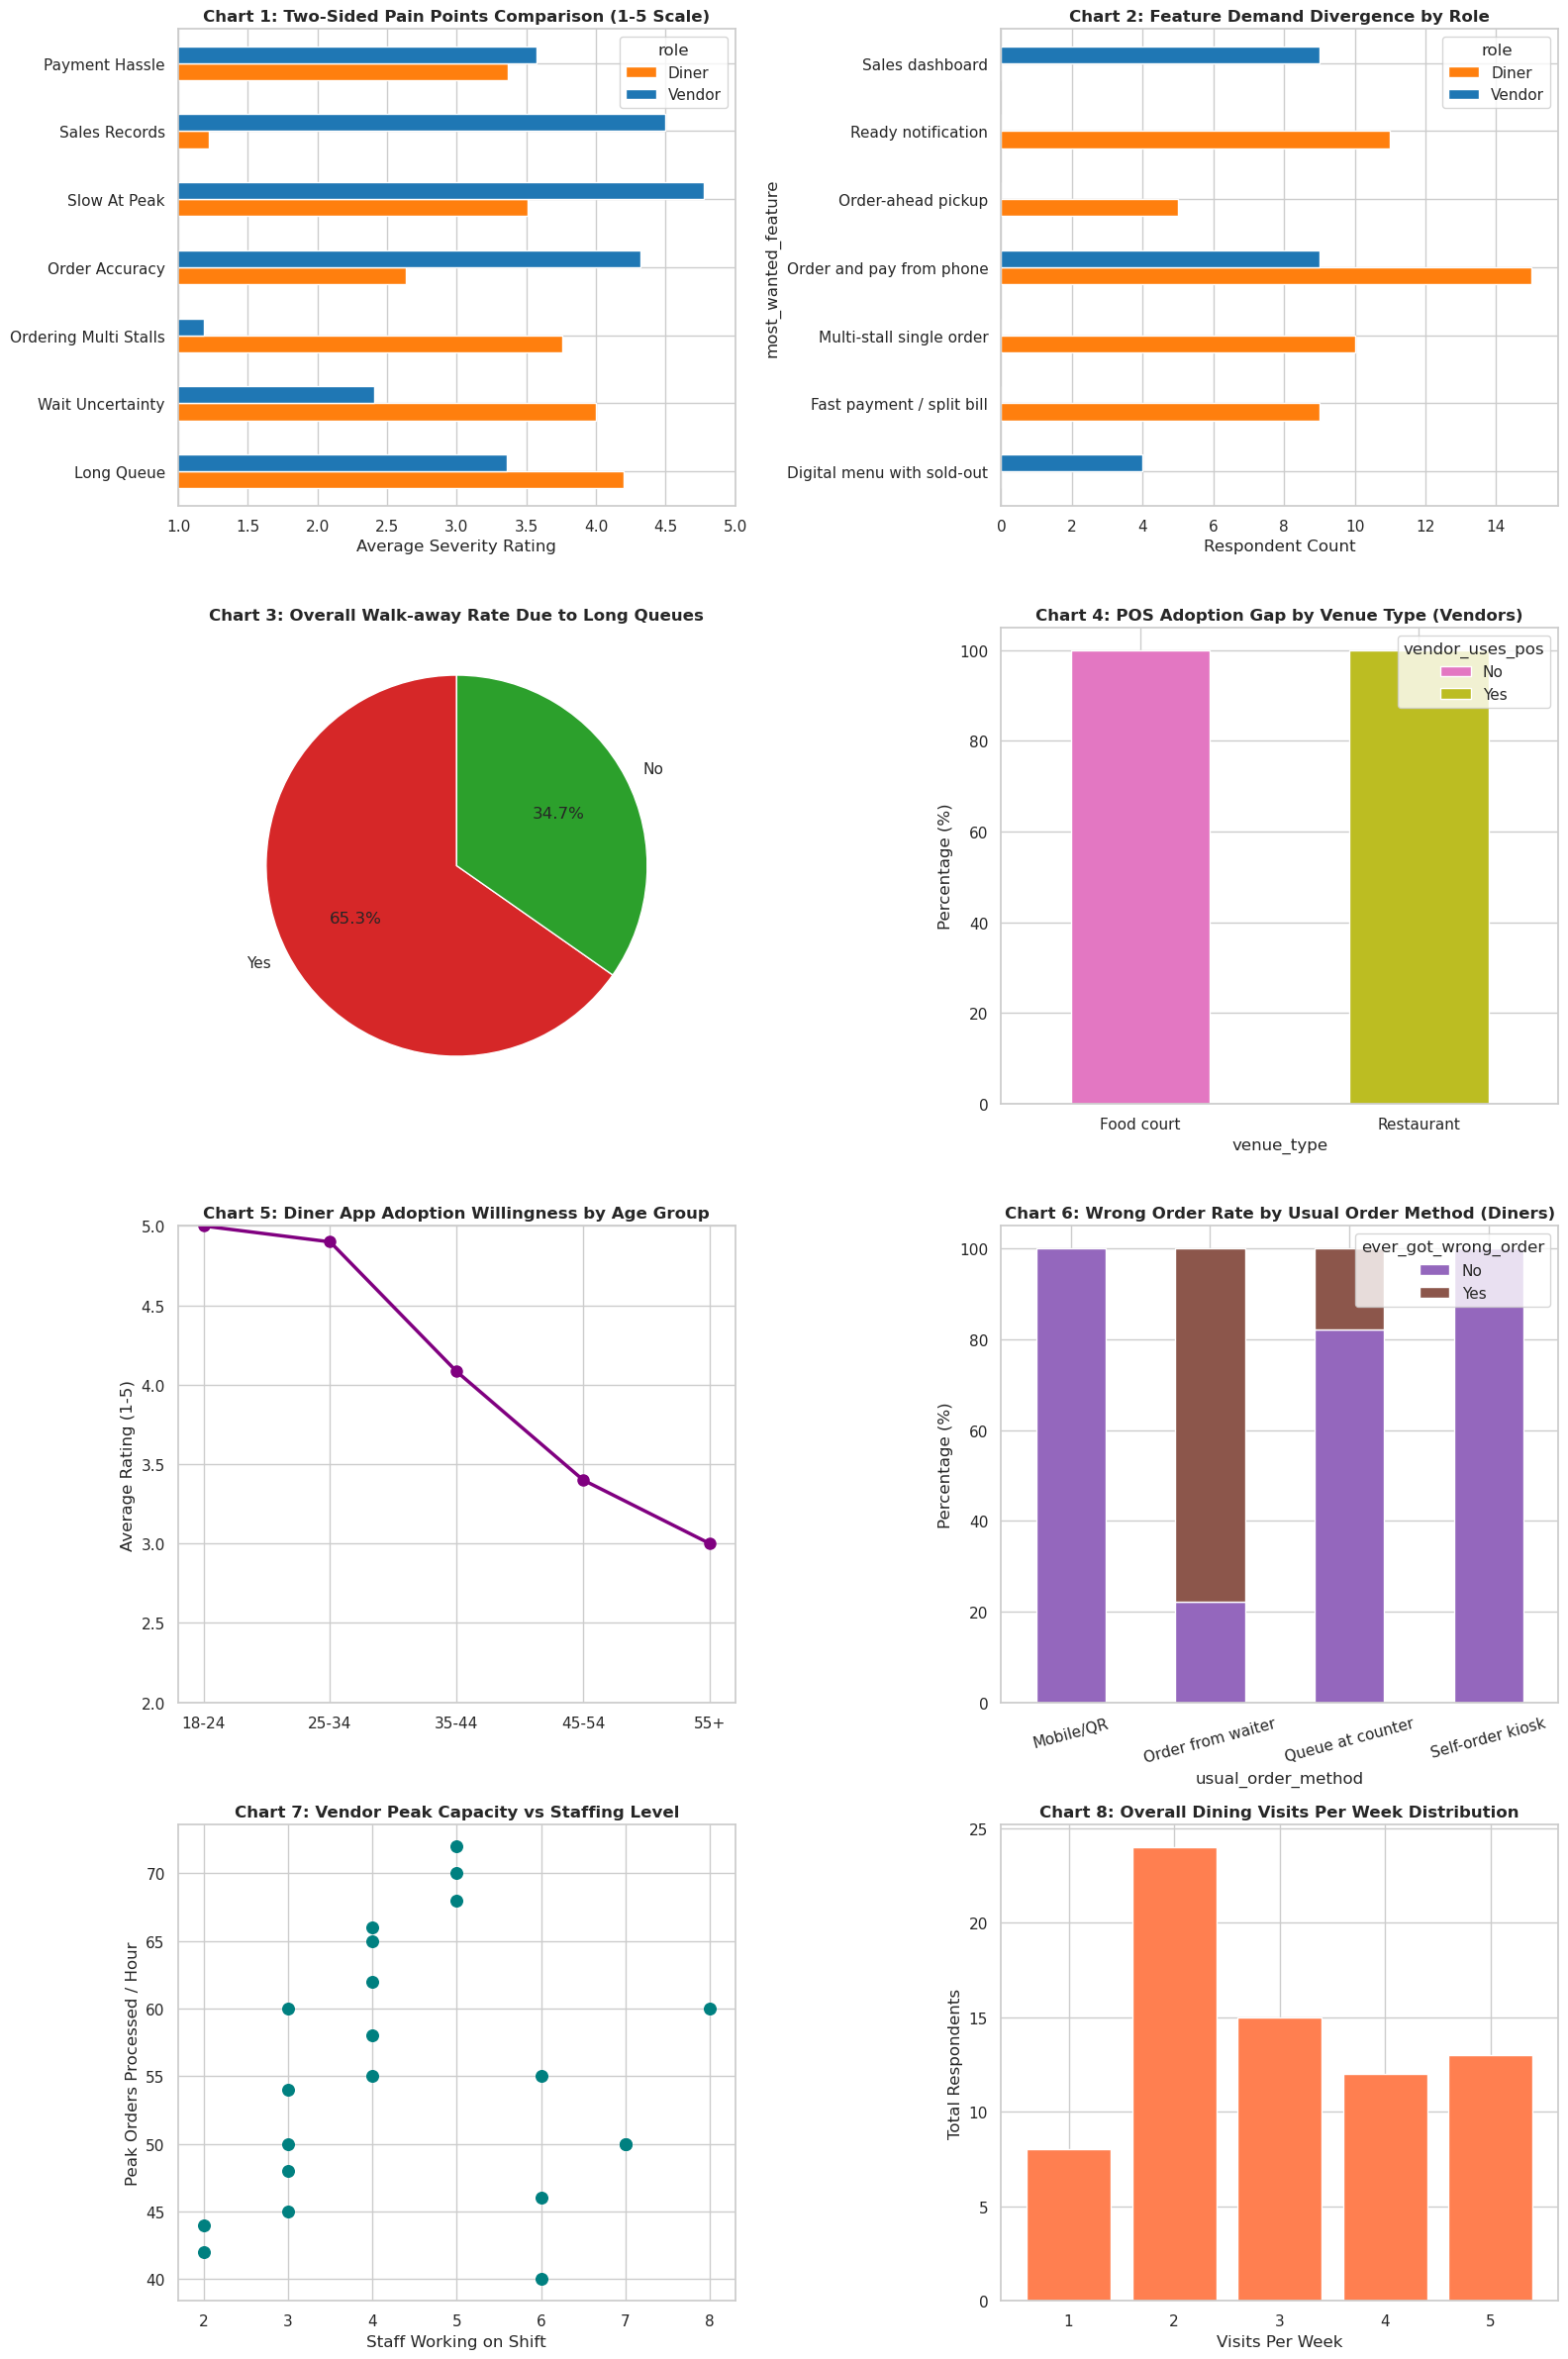

In [22]:
# =========================================================================
# PART 5: VISUALIZATIONS (8 Subplot Dashboard)
# =========================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

# Chart 1: Two-Sided Pain Point Comparison
pain_labels = [p.replace('pain_', '').replace('_', ' ').title() for p in all_pains]
pain_plot_df = df.groupby('role')[all_pains].mean().T
pain_plot_df.index = pain_labels
pain_plot_df.plot(kind='barh', ax=axes[0, 0], color=['#ff7f0e', '#1f77b4'])
axes[0, 0].set_title('Chart 1: Two-Sided Pain Points Comparison (1-5 Scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Average Severity Rating')
axes[0, 0].set_xlim(1, 5)

# Chart 2: Feature Demand Divergence
feature_cross = pd.crosstab(df['most_wanted_feature'], df['role'])
feature_cross.plot(kind='barh', ax=axes[0, 1], color=['#ff7f0e', '#1f77b4'])
axes[0, 1].set_title('Chart 2: Feature Demand Divergence by Role', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Respondent Count')

# Chart 3: Universal Walk-away Rate
left_counts = df['ever_left_due_to_queue'].value_counts()
axes[1, 0].pie(left_counts, labels=left_counts.index, autopct='%1.1f%%', startangle=90, colors=['#d62728', '#2ca02c'])
axes[1, 0].set_title('Chart 3: Overall Walk-away Rate Due to Long Queues', fontsize=12, fontweight='bold')

# Chart 4: Vendor POS Adoption Gap
pos_cross = pd.crosstab(vendor_df['venue_type'], vendor_df['vendor_uses_pos'], normalize='index') * 100
pos_cross.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#e377c2', '#bcbd22'])
axes[1, 1].set_title('Chart 4: POS Adoption Gap by Venue Type (Vendors)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].tick_params(axis='x', rotation=0)

# Chart 5: App Willingness across Age Groups
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_will_mean = diner_df.groupby('age_group')['willingness_to_use_app'].mean().reindex(age_order)
axes[2, 0].plot(age_will_mean.index, age_will_mean.values, marker='o', linewidth=2.5, markersize=8, color='purple')
axes[2, 0].set_title('Chart 5: Diner App Adoption Willingness by Age Group', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('Average Rating (1-5)')
axes[2, 0].set_ylim(2, 5)

# Chart 6: Order Method vs Wrong Order Error Rate
wrong_order_cross = pd.crosstab(diner_df['usual_order_method'], diner_df['ever_got_wrong_order'], normalize='index') * 100
wrong_order_cross.plot(kind='bar', stacked=True, ax=axes[2, 1], color=['#9467bd', '#8c564b'])
axes[2, 1].set_title('Chart 6: Wrong Order Rate by Usual Order Method (Diners)', fontsize=12, fontweight='bold')
axes[2, 1].set_ylabel('Percentage (%)')
axes[2, 1].tick_params(axis='x', rotation=15)

# Chart 7: Vendor Peak Orders/Hour vs Staffing Level
axes[3, 0].scatter(vendor_df['vendor_staff_on_shift'], vendor_df['vendor_orders_per_peak_hour'], color='teal', s=70)
axes[3, 0].set_title('Chart 7: Vendor Peak Capacity vs Staffing Level', fontsize=12, fontweight='bold')
axes[3, 0].set_xlabel('Staff Working on Shift')
axes[3, 0].set_ylabel('Peak Orders Processed / Hour')

# Chart 8: Weekly Dining Frequency
visit_counts = df['visits_per_week'].value_counts().sort_index()
axes[3, 1].bar(visit_counts.index.astype(str), visit_counts.values, color='coral')
axes[3, 1].set_title('Chart 8: Overall Dining Visits Per Week Distribution', fontsize=12, fontweight='bold')
axes[3, 1].set_xlabel('Visits Per Week')
axes[3, 1].set_ylabel('Total Respondents')

plt.tight_layout()
plt.show()

In [34]:
# =========================================================================
# PART 6: ADDITIONAL DINER CORRELATION ANALYSIS
# =========================================================================
print("\n" + "=" * 65)
print("【PART 6: ADDITIONAL DINER CORRELATION ANALYSIS】")

# Convert binary categorical column ('Yes'/'No') to numeric (1/0)
ever_left_binary = diner_df['ever_left_due_to_queue'].map({'Yes': 1, 'No': 0})

# 1. Correlation: pain_wait_uncertainty vs ever_left_due_to_queue
corr_wait_uncertainty = diner_df['pain_wait_uncertainty'].corr(ever_left_binary)

# 2. Correlation: pain_long_queue vs ever_left_due_to_queue
corr_long_queue = diner_df['pain_long_queue'].corr(ever_left_binary)

print(f"Correlation (pain_wait_uncertainty vs ever_left_due_to_queue): {corr_wait_uncertainty:.4f}")
print(f"Correlation (pain_long_queue vs ever_left_due_to_queue): {corr_long_queue:.4f}")


【PART 6: ADDITIONAL DINER CORRELATION ANALYSIS】
Correlation (pain_wait_uncertainty vs ever_left_due_to_queue): 0.5873
Correlation (pain_long_queue vs ever_left_due_to_queue): 0.6492
